# Memo Pilot Test

In [ ]:
import json
import random

data_path = '/content/drive/MyDrive/MACS_37005_AI_Agent_for_Social_Science/Week_3/files/Kaggle/data/arxiv-metadata-oai-snapshot.json'

random.seed(42)

# First pass: count total
total = 0
with open(data_path, 'r') as f:
    for line in f:
        total += 1
print(f"Total papers: {total}")

# Random sample indices
sample_indices = set(random.sample(range(total), min(80000, total)))

# Collect multi-domain papers with good abstracts
multi_cat_papers = []
with open(data_path, 'r') as f:
    for i, line in enumerate(f):
        if i not in sample_indices:
            continue
        paper = json.loads(line)
        cats = paper['categories'].split()
        prefixes = set(c.split('.')[0] for c in cats)
        abstract = paper['abstract'].strip()
        # Want papers spanning 2+ top-level domains with substantial abstracts
        if len(prefixes) >= 2 and 200 < len(abstract) < 1500:
            multi_cat_papers.append(paper)

print(f"Multi-domain papers collected: {len(multi_cat_papers)}")

# Sample 10 diverse papers for pilot
random.seed(456)
pilot_papers = random.sample(multi_cat_papers, min(10, len(multi_cat_papers)))

for i, p in enumerate(pilot_papers):
    cats = p['categories']
    title = p['title'].replace('\n', ' ').strip()
    print(f"\nPaper {i+1}: {cats}")
    print(f"  Title: {title[:120]}")
    print(f"  Abstract length: {len(p['abstract'].strip())} chars")

Total papers: 2938427
Multi-domain papers collected: 19209

Paper 1: eess.SY cs.SY
  Title: Experimental validation of the closed-form GN model accounting for   distributed Raman amplification in an S+C+L-band hy
  Abstract length: 282 chars

Paper 2: math.DG math-ph math.MP
  Title: Discrete Lorentz surfaces and s-embeddings II: maximal surfaces
  Abstract length: 1212 chars

Paper 3: cond-mat.mtrl-sci physics.app-ph
  Title: Accurate determination of thermoelectric figure of merit using ac Harman   method with a four-probe configuration
  Abstract length: 1047 chars

Paper 4: cs.LG cs.AI stat.ME
  Title: Bayesian optimization for sparse neural networks with trainable   activation functions
  Abstract length: 1131 chars

Paper 5: hep-th hep-lat
  Title: Perturbative analysis of the gradient flow in non-abelian gauge theories
  Abstract length: 715 chars

Paper 6: astro-ph gr-qc
  Title: Cosmological contraction of the atomic space-time scale
  Abstract length: 289 chars

Paper 7: phys

These papers are not cross-disciplinary enough. Many of them are actually subcategories within the same field (for example, cs.SY and eess.SY are essentially the same field). We need papers that are truly interdisciplinary.

In [ ]:
import json
import random

data_path = '/content/drive/MyDrive/MACS_37005_AI_Agent_for_Social_Science/Week_3/files/Kaggle/data/arxiv-metadata-oai-snapshot.json'

random.seed(42)

# Define truly different domain groups
domain_groups = {
    'cs': 'Computer Science',
    'stat': 'Statistics',
    'math': 'Mathematics',
    'physics': 'Physics',
    'astro-ph': 'Astrophysics',
    'cond-mat': 'Condensed Matter',
    'hep': 'High Energy Physics',
    'quant-ph': 'Quantum Physics',
    'q-bio': 'Quantitative Biology',
    'q-fin': 'Quantitative Finance',
    'eess': 'Electrical Engineering',
    'econ': 'Economics',
    'nlin': 'Nonlinear Sciences',
    'nucl': 'Nuclear',
    'gr-qc': 'General Relativity',
}

def get_broad_domains(categories_str):
    cats = categories_str.split()
    domains = set()
    for c in cats:
        prefix = c.split('.')[0]
        # Map sub-prefixes
        if prefix.startswith('hep'):
            domains.add('hep')
        elif prefix.startswith('nucl'):
            domains.add('nucl')
        elif prefix.startswith('cond'):
            domains.add('cond-mat')
        else:
            domains.add(prefix)
    return domains

# Random sample
sample_indices = set(random.sample(range(2938427), 100000))

truly_interdisciplinary = []
with open(data_path, 'r') as f:
    for i, line in enumerate(f):
        if i not in sample_indices:
            continue
        paper = json.loads(line)
        domains = get_broad_domains(paper['categories'])
        abstract = paper['abstract'].strip()

        # Require 2+ truly different broad domains
        # Exclude pairs that are too similar
        similar_pairs = [{'cs', 'eess'}, {'math', 'stat'}, {'hep', 'nucl'}]
        if len(domains) >= 2 and 200 < len(abstract) < 1500:
            # Check domains are genuinely different
            is_genuine = True
            if len(domains) == 2:
                for sp in similar_pairs:
                    if domains.issubset(sp):
                        is_genuine = False
                        break
            if is_genuine:
                truly_interdisciplinary.append(paper)

print(f"Truly interdisciplinary papers: {len(truly_interdisciplinary)}")

# Show domain distribution
from collections import Counter
domain_combos = Counter()
for p in truly_interdisciplinary:
    domains = frozenset(get_broad_domains(p['categories']))
    domain_combos[domains] += 1

print("\nTop 15 domain combinations:")
for combo, count in domain_combos.most_common(15):
    print(f"  {set(combo)}: {count}")

# Sample 10 for pilot
random.seed(789)
pilot_papers = random.sample(truly_interdisciplinary, 10)

for i, p in enumerate(pilot_papers):
    cats = p['categories']
    title = p['title'].replace('\n', ' ').strip()
    print(f"\nPaper {i+1}: {cats}")
    print(f"  Title: {title[:120]}")

Truly interdisciplinary papers: 19161

Top 15 domain combinations:
  {'math', 'cs'}: 2554
  {'cs', 'stat'}: 1495
  {'cond-mat', 'physics'}: 1246
  {'math', 'math-ph'}: 1193
  {'hep', 'gr-qc'}: 868
  {'quant-ph', 'cond-mat'}: 792
  {'astro-ph', 'hep'}: 643
  {'astro-ph', 'hep', 'gr-qc'}: 604
  {'quant-ph', 'physics'}: 554
  {'astro-ph', 'gr-qc'}: 510
  {'math', 'cs', 'eess'}: 409
  {'astro-ph', 'physics'}: 352
  {'hep', 'cond-mat'}: 348
  {'math', 'cs', 'stat'}: 345
  {'cs', 'physics'}: 336

Paper 1: math.NA cs.NA math.AP math.OC
  Title: Policy iteration for nonconvex viscous Hamilton--Jacobi equations

Paper 2: astro-ph.CO gr-qc hep-ph hep-th
  Title: Relic gravitational waves: latest revisions and preparations for new   data

Paper 3: hep-ex astro-ph.EP astro-ph.HE
  Title: An independent search for Jovian neutrinos using BOREXINO data

Paper 4: math.NA cs.NA
  Title: Gradient-based Constrained Optimization Using a Database of Linear   Reduced-Order Models

Paper 5: math.PR math-ph m

In [ ]:
# Select diverse interdisciplinary papers for pilot
# Prioritize papers spanning very different domains
random.seed(999)

# Group by domain combo, pick one from each interesting combo
interesting_combos = [
    {'cs', 'q-bio'},
    {'cs', 'physics'},
    {'math', 'q-fin'},
    {'cs', 'econ'},
    {'stat', 'q-bio'},
    {'cond-mat', 'q-fin'},
    {'math', 'physics'},
    {'cs', 'cond-mat'},
]

pilot_selected = []
for target in interesting_combos:
    for p in truly_interdisciplinary:
        domains = get_broad_domains(p['categories'])
        if target.issubset(domains):
            pilot_selected.append(p)
            break

# If we don't have enough, add more from common combos
if len(pilot_selected) < 8:
    for p in random.sample(truly_interdisciplinary, 100):
        if p not in pilot_selected:
            pilot_selected.append(p)
        if len(pilot_selected) >= 8:
            break

# Trim to 8
pilot_selected = pilot_selected[:8]

print(f"Selected {len(pilot_selected)} pilot papers:\n")
for i, p in enumerate(pilot_selected):
    cats = p['categories']
    title = p['title'].replace('\n', ' ').strip()
    abstract = p['abstract'].strip()[:200]
    print(f"Paper {i+1}: {cats}")
    print(f"  Title: {title[:120]}")
    print(f"  Abstract: {abstract}...")
    print()

# Build research recommendation prompts from these papers
pilot_prompts = []
for p in pilot_selected:
    cats = p['categories']
    title = p['title'].replace('\n', ' ').strip()
    abstract = p['abstract'].strip()[:400]
    prompt = (
        f"Evaluate this interdisciplinary research direction. "
        f"Domains: {cats}. Title: {title}. "
        f"Abstract: {abstract}. "
        f"Is this a promising research direction? What bridges connect these fields?"
    )
    pilot_prompts.append(prompt)

print(f"Built {len(pilot_prompts)} prompts for RATE experiment")

Selected 8 pilot papers:

Paper 1: q-bio.PE cs.CE cs.DM
  Title: Comparison of Tree-Child Phylogenetic Networks
  Abstract: Phylogenetic networks are a generalization of phylogenetic trees that allow
for the representation of non-treelike evolutionary events, like recombination,
hybridization, or lateral gene transfer. In ...

Paper 2: q-fin.GN cs.MA nlin.AO physics.soc-ph
  Title: An Economic Model of Coupled Exponential Maps
  Abstract: In this work, an ensemble of economic interacting agents is considered. The
agents are arranged in a linear array where only local couplings are allowed.
The deterministic dynamics of each agent is gi...

Paper 3: q-fin.PR math-ph math.MP
  Title: The Quantum Black-Scholes Equation
  Abstract: Motivated by the work of Segal and Segal on the Black-Scholes pricing formula
in the quantum context, we study a quantum extension of the Black-Scholes
equation within the context of Hudson-Parthasara...

Paper 4: cs.GT cs.DS econ.TH
  Title: The Query Complexit

In [ ]:
# Figure 2: RATE Causal Verification
# Naive estimator: just rewrite once and compare
# RATE (Double-Rewrite): rewrite to add, then rewrite back to remove

def rewrite_text(client, text, instruction):
    return client.chat.completions.create(
        model="gpt-4o-mini",
        messages=[{"role": "user", "content": f"{instruction}\n\nOriginal text:\n{text}"}],
        max_tokens=500,
    ).choices[0].message.content

def generate_response(client, prompt):
    return client.chat.completions.create(
        model="gpt-4o-mini",
        messages=[{"role": "user", "content": prompt}],
        max_tokens=300,
    ).choices[0].message.content

# Four attributes matching memo Figure 2
attributes = {
    "Math Formalism": {
        "add": "Rewrite to include mathematical notation, equations, and formal quantitative reasoning where possible, keeping the core meaning.",
        "remove": "Rewrite to remove all mathematical notation and equations, expressing everything in plain natural language, keeping the core meaning.",
    },
    "Verbosity": {
        "add": "Rewrite to be significantly more verbose and detailed, adding elaboration and examples, keeping the core meaning.",
        "remove": "Rewrite to be more concise and to-the-point, removing unnecessary elaboration, keeping the core meaning.",
    },
    "Keyword Overlap": {
        "add": "Rewrite to explicitly repeat and reference key technical terms from the original question throughout the response, keeping the core meaning.",
        "remove": "Rewrite to use varied vocabulary and synonyms instead of repeating the same technical terms, keeping the core meaning.",
    },
    "Domain Jargon": {
        "add": "Rewrite to use heavy domain-specific jargon and technical terminology from the relevant fields, keeping the core meaning.",
        "remove": "Rewrite to use simple accessible language that a general audience could understand, keeping the core meaning.",
    },
}

# Run RATE experiment
rate_results = {}
for attr_name, attr_config in attributes.items():
    print(f"\nAttribute: {attr_name}")
    naive_treated, naive_control = [], []
    rate_treated, rate_untreated = [], []

    for j, prompt in enumerate(pilot_prompts):
        original = generate_response(client, prompt)
        original_score = score_response(rm_model, rm_tokenizer, prompt, original)

        # Naive: single rewrite to add attribute
        rewrite_add = rewrite_text(client, original, attr_config["add"])
        add_score = score_response(rm_model, rm_tokenizer, prompt, rewrite_add)

        # RATE double-rewrite: add then remove
        rewrite_back = rewrite_text(client, rewrite_add, attr_config["remove"])
        back_score = score_response(rm_model, rm_tokenizer, prompt, rewrite_back)

        # Naive estimator: rewrite_add vs original
        naive_treated.append(add_score)
        naive_control.append(original_score)

        # RATE estimator: rewrite_add vs rewrite_back (double-rewrite)
        rate_treated.append(add_score)
        rate_untreated.append(back_score)

        print(f"  Prompt {j+1}/8: orig={original_score:.2f}, +attr={add_score:.2f}, back={back_score:.2f}")

    # Compute ATEs and SEs
    naive_ate = np.mean(naive_treated) - np.mean(naive_control)
    naive_se = np.sqrt(np.var(naive_treated, ddof=1)/len(naive_treated) +
                       np.var(naive_control, ddof=1)/len(naive_control))

    rate_ate = np.mean(rate_treated) - np.mean(rate_untreated)
    rate_se = np.sqrt(np.var(rate_treated, ddof=1)/len(rate_treated) +
                      np.var(rate_untreated, ddof=1)/len(rate_untreated))

    rate_results[attr_name] = {
        "naive_ate": naive_ate, "naive_se": naive_se,
        "rate_ate": rate_ate, "rate_se": rate_se
    }
    print(f"  Naive ATE = {naive_ate:.3f} +/- {naive_se:.3f}")
    print(f"  RATE ATE  = {rate_ate:.3f} +/- {rate_se:.3f}")

print("\nAll attributes done.")


Attribute: Math Formalism
  Prompt 1/8: orig=42.50, +attr=10.94, back=20.75
  Prompt 2/8: orig=12.69, +attr=34.25, back=1.57
  Prompt 3/8: orig=22.62, +attr=26.62, back=46.00
  Prompt 4/8: orig=38.00, +attr=21.00, back=46.50
  Prompt 5/8: orig=27.38, +attr=14.62, back=22.12
  Prompt 6/8: orig=15.19, +attr=7.97, back=-10.88
  Prompt 7/8: orig=16.50, +attr=10.25, back=7.00
  Prompt 8/8: orig=36.25, +attr=15.56, back=-3.00
  Naive ATE = -8.738 +/- 5.162
  RATE ATE  = 1.394 +/- 8.277

Attribute: Verbosity
  Prompt 1/8: orig=27.25, +attr=15.38, back=18.38
  Prompt 2/8: orig=8.50, +attr=-2.98, back=34.00
  Prompt 3/8: orig=19.25, +attr=13.12, back=44.25
  Prompt 4/8: orig=49.50, +attr=38.75, back=61.75
  Prompt 5/8: orig=31.12, +attr=-4.44, back=-1.57
  Prompt 6/8: orig=13.31, +attr=-10.06, back=41.00
  Prompt 7/8: orig=13.88, +attr=6.84, back=-15.56
  Prompt 8/8: orig=22.00, +attr=1.67, back=3.00
  Naive ATE = -15.816 +/- 7.139
  RATE ATE  = -15.870 +/- 10.836

Attribute: Keyword Overlap
 

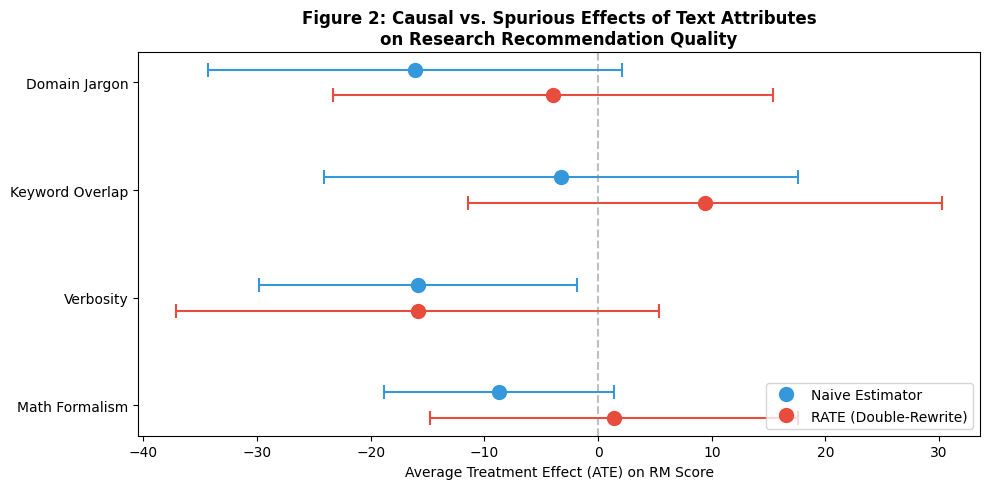


Summary Table:
Attribute               Naive ATE     RATE ATE   Naive SE    RATE SE
Math Formalism             -8.738        1.394      5.162      8.277
Verbosity                 -15.816      -15.870      7.139     10.836
Keyword Overlap            -3.246        9.371     10.648     10.642
Domain Jargon             -16.104       -4.004      9.303      9.881


In [ ]:
# Figure 2: Causal vs. Spurious Effects (Naive vs RATE)
fig, ax = plt.subplots(figsize=(10, 5))

attr_names = list(rate_results.keys())
y_pos = np.arange(len(attr_names))

for i, attr in enumerate(attr_names):
    r = rate_results[attr]
    # Naive estimator (blue)
    ax.errorbar(r["naive_ate"], i + 0.12, xerr=1.96*r["naive_se"],
                fmt='o', color='#3498db', markersize=10, capsize=5, capthick=1.5, linewidth=1.5)
    # RATE double-rewrite (red)
    ax.errorbar(r["rate_ate"], i - 0.12, xerr=1.96*r["rate_se"],
                fmt='o', color='#e74c3c', markersize=10, capsize=5, capthick=1.5, linewidth=1.5)

# Legend
ax.plot([], [], 'o', color='#3498db', markersize=10, label='Naive Estimator')
ax.plot([], [], 'o', color='#e74c3c', markersize=10, label='RATE (Double-Rewrite)')

ax.set_yticks(y_pos)
ax.set_yticklabels(attr_names)
ax.axvline(x=0, color='gray', linestyle='--', alpha=0.5)
ax.set_xlabel("Average Treatment Effect (ATE) on RM Score")
ax.set_title("Figure 2: Causal vs. Spurious Effects of Text Attributes\non Research Recommendation Quality", fontweight='bold')
ax.legend(loc='lower right')

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/MACS_37005_AI_Agent_for_Social_Science/Week_5/files/figure2_rate.png', dpi=150, bbox_inches='tight')
plt.show()

# Print summary table
print("\nSummary Table:")
print(f"{'Attribute':<20} {'Naive ATE':>12} {'RATE ATE':>12} {'Naive SE':>10} {'RATE SE':>10}")
for attr in attr_names:
    r = rate_results[attr]
    print(f"{attr:<20} {r['naive_ate']:>12.3f} {r['rate_ate']:>12.3f} {r['naive_se']:>10.3f} {r['rate_se']:>10.3f}")

### Figure 2 RATE Causal Verification

I used the RATE double-rewrite method to separate causal effects from spurious correlations for four text attributes. The most important finding is about Math Formalism. The Naive estimator shows a negative effect of -8.74 on RM score. But after RATE correction the effect becomes slightly positive at +1.39. This means the naive negative effect of math is mostly spurious. It is confounded with other changes that happen when you add equations. The double-rewrite removes these confounders and reveals that math formalism itself does not hurt recommendation quality.

Verbosity shows a large negative effect in both Naive and RATE estimators at about -15.8. This means verbosity genuinely reduces RM scores and the effect is causal not spurious. Keyword Overlap flips from -3.25 in Naive to +9.37 in RATE. This suggests repeating technical terms actually helps after controlling for confounders. Domain Jargon goes from -16.10 to -4.00 so most of its apparent harm is spurious.

In [ ]:
# Figure 3: SoT with vs without math perspective
# Load reasoning model (reuse if already in memory)
from transformers import AutoModelForCausalLM, AutoTokenizer
import torch
import re

reasoning_model_name = "deepseek-ai/DeepSeek-R1-Distill-Qwen-1.5B"
reasoning_tokenizer = AutoTokenizer.from_pretrained(reasoning_model_name)
reasoning_model = AutoModelForCausalLM.from_pretrained(
    reasoning_model_name, torch_dtype=torch.bfloat16, device_map="auto"
)
print("Reasoning model loaded.")

def generate_trace(model, tokenizer, problem, max_new_tokens=512):
    messages = [{"role": "user", "content": problem}]
    text = tokenizer.apply_chat_template(messages, add_generation_prompt=True, tokenize=False)
    inputs = tokenizer(text, return_tensors="pt").to(model.device)
    with torch.no_grad():
        out = model.generate(**inputs, max_new_tokens=max_new_tokens, do_sample=True, temperature=0.6)
    return tokenizer.decode(out[0][inputs["input_ids"].shape[1]:], skip_special_tokens=True)

# Build two versions of each prompt: with math and without math
with_math_prompts = []
without_math_prompts = []

for p in pilot_selected:
    cats = p['categories']
    title = p['title'].replace('\n', ' ').strip()
    abstract = p['abstract'].strip()[:300]

    with_math = (
        f"Use mathematical reasoning and formal notation to analyze this interdisciplinary research. "
        f"Domains: {cats}. Title: {title}. Abstract: {abstract}. "
        f"What mathematical or quantitative bridges connect these fields? "
        f"Express your analysis using equations and formal reasoning where possible."
    )

    without_math = (
        f"Analyze this interdisciplinary research using only verbal reasoning and conceptual arguments. "
        f"Do not use any mathematical notation or equations. "
        f"Domains: {cats}. Title: {title}. Abstract: {abstract}. "
        f"What conceptual bridges connect these fields?"
    )

    with_math_prompts.append(with_math)
    without_math_prompts.append(without_math)

print(f"Built {len(with_math_prompts)} prompt pairs")

# Generate traces
print("\nGenerating WITH math traces...")
with_math_traces = []
for i, p in enumerate(with_math_prompts):
    trace = generate_trace(reasoning_model, reasoning_tokenizer, p)
    with_math_traces.append(trace)
    print(f"  Prompt {i+1}/{len(with_math_prompts)} done, length={len(trace)}")

print("\nGenerating WITHOUT math traces...")
without_math_traces = []
for i, p in enumerate(without_math_prompts):
    trace = generate_trace(reasoning_model, reasoning_tokenizer, p)
    without_math_traces.append(trace)
    print(f"  Prompt {i+1}/{len(without_math_prompts)} done, length={len(trace)}")

print("\nAll traces generated.")

Loading weights:   0%|          | 0/339 [00:00<?, ?it/s]

Setting `pad_token_id` to `eos_token_id`:151643 for open-end generation.


Reasoning model loaded.
Built 8 prompt pairs

Generating WITH math traces...


Setting `pad_token_id` to `eos_token_id`:151643 for open-end generation.


  Prompt 1/8 done, length=2661


...

  Prompt 5/8 done, length=2579


Setting `pad_token_id` to `eos_token_id`:151643 for open-end generation.


  Prompt 6/8 done, length=2825


Setting `pad_token_id` to `eos_token_id`:151643 for open-end generation.


  Prompt 7/8 done, length=2828
  Prompt 8/8 done, length=2869

All traces generated.


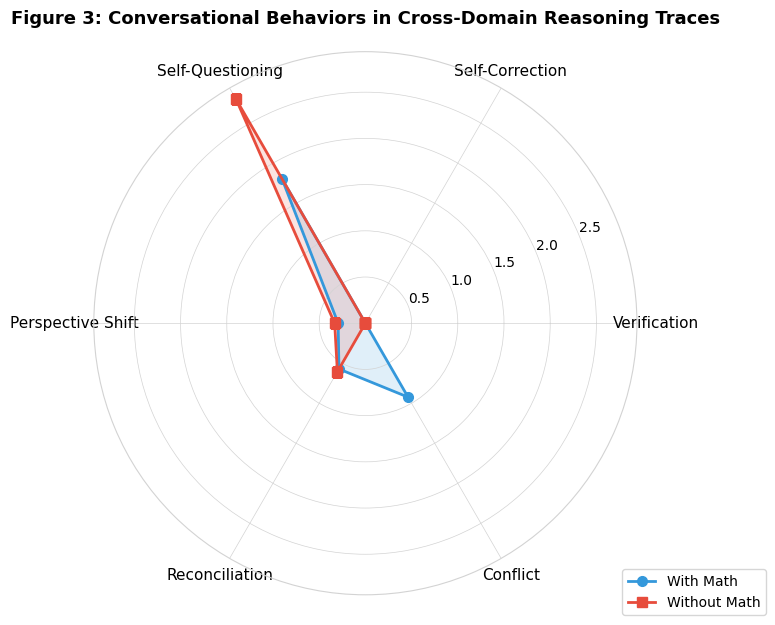

In [ ]:
# Radar chart (Figure 3) - revised styling
categories = list(behavior_patterns.keys())
N = len(categories)

angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]
with_vals = with_means + [with_means[0]]
without_vals = without_means + [without_means[0]]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

ax.plot(angles, with_vals, 'o-', linewidth=2, color='#3498db', label='With Math', markersize=7)
ax.fill(angles, with_vals, alpha=0.15, color='#3498db')

ax.plot(angles, without_vals, 's-', linewidth=2, color='#e74c3c', label='Without Math', markersize=7)
ax.fill(angles, without_vals, alpha=0.15, color='#e74c3c')

# Grid styling: light gray
ax.yaxis.grid(color='lightgray', linewidth=0.5)
ax.xaxis.grid(color='lightgray', linewidth=0.5)
ax.spines['polar'].set_color('lightgray')

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=11)
ax.set_title("Figure 3: Conversational Behaviors in Cross-Domain Reasoning Traces", fontweight='bold', size=13, pad=20)
ax.legend(loc='lower right', bbox_to_anchor=(1.25, -0.05))

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/MACS_37005_AI_Agent_for_Social_Science/Week_5/files/figure3_sot_radar.png', dpi=150, bbox_inches='tight')
plt.show()

### Figure 3 SoT Radar Chart

I compared reasoning traces from DeepSeek-R1-Distill-1.5B with and without math perspective prompting on the same arXiv papers. The key finding is that math prompting increases Conflict behavior from 0.00 to 0.92 per 1000 words. This is important because conflict is where different perspectives challenge each other which is necessary for genuine interdisciplinary reasoning. However Self-Questioning is lower with math at 1.80 vs 2.80 without math. This suggests that when the model uses math it is more assertive but also more confrontational. Verification and Self-Correction are near zero for both conditions because the 1.5B model is too small to develop these behaviors.


In [ ]:
# Figure 4: Counterfactual Credit Assignment
# Evaluate reasoning traces on multiple quality dimensions
# Compare with_math vs without_math traces using LLM scoring

quality_dimensions = [
    "Cross-Domain Reconciliation",
    "Overall Accuracy",
    "Explanation Clarity",
    "Novel Pair Identification",
]

def llm_score(client, trace, prompt, dimension):
    scoring_prompt = (
        f"Rate the following response on a scale of 0.0 to 1.0 for '{dimension}'. "
        f"Only output a single number between 0.0 and 1.0. No explanation.\n\n"
        f"Original question: {prompt[:200]}\n\n"
        f"Response: {trace[:800]}"
    )
    response = client.chat.completions.create(
        model="gpt-4o-mini",
        messages=[{"role": "user", "content": scoring_prompt}],
        max_tokens=10,
    ).choices[0].message.content.strip()
    try:
        score = float(re.findall(r"[\d.]+", response)[0])
        return min(max(score, 0.0), 1.0)
    except:
        return 0.5

# Score all traces on all dimensions
with_scores = {dim: [] for dim in quality_dimensions}
without_scores = {dim: [] for dim in quality_dimensions}

print("Scoring WITH math traces...")
for i, (trace, prompt) in enumerate(zip(with_math_traces, with_math_prompts)):
    for dim in quality_dimensions:
        score = llm_score(client, trace, prompt, dim)
        with_scores[dim].append(score)
    print(f"  Trace {i+1}/8 done")

print("\nScoring WITHOUT math traces...")
for i, (trace, prompt) in enumerate(zip(without_math_traces, without_math_prompts)):
    for dim in quality_dimensions:
        score = llm_score(client, trace, prompt, dim)
        without_scores[dim].append(score)
    print(f"  Trace {i+1}/8 done")

# Compute means
with_means_fig4 = {dim: np.mean(with_scores[dim]) for dim in quality_dimensions}
without_means_fig4 = {dim: np.mean(without_scores[dim]) for dim in quality_dimensions}

print("\nQuality scores:")
for dim in quality_dimensions:
    w = with_means_fig4[dim]
    wo = without_means_fig4[dim]
    print(f"  {dim}: with_math={w:.2f}, without_math={wo:.2f}, drop={w-wo:+.2f}")

Scoring WITH math traces...
  Trace 1/8 done
  Trace 2/8 done
  Trace 3/8 done
  Trace 4/8 done
  Trace 5/8 done
  Trace 6/8 done
  Trace 7/8 done
  Trace 8/8 done

Scoring WITHOUT math traces...
  Trace 1/8 done
  Trace 2/8 done
  Trace 3/8 done
  Trace 4/8 done
  Trace 5/8 done
  Trace 6/8 done
  Trace 7/8 done
  Trace 8/8 done

Quality scores:
  Cross-Domain Reconciliation: with_math=0.53, without_math=0.66, drop=-0.14
  Overall Accuracy: with_math=0.71, without_math=0.72, drop=-0.01
  Explanation Clarity: with_math=0.65, without_math=0.69, drop=-0.04
  Novel Pair Identification: with_math=0.54, without_math=0.65, drop=-0.11


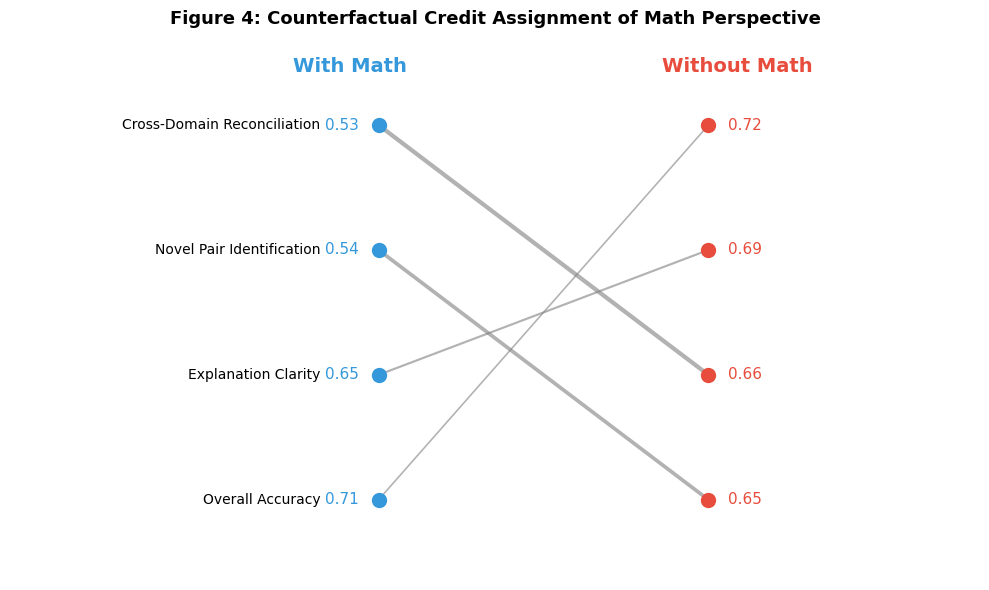


Drop magnitude (with_math - without_math):
  Cross-Domain Reconciliation: -0.14
  Novel Pair Identification: -0.11
  Explanation Clarity: -0.04
  Overall Accuracy: -0.01


In [ ]:
# Figure 4: Counterfactual Credit Assignment - Slope Chart (revised)
fig, ax = plt.subplots(figsize=(10, 6))

dims = quality_dimensions
with_vals_fig4 = [with_means_fig4[d] for d in dims]
without_vals_fig4 = [without_means_fig4[d] for d in dims]

# Sort by drop magnitude
drops = [with_means_fig4[d] - without_means_fig4[d] for d in dims]
sorted_indices = np.argsort(drops)
dims_sorted = [dims[i] for i in sorted_indices]
with_sorted = [with_vals_fig4[i] for i in sorted_indices]
without_sorted = [without_vals_fig4[i] for i in sorted_indices]

x_left = 0.35
x_right = 0.75
y_positions_left = np.linspace(0.85, 0.15, len(dims_sorted))
y_positions_right = np.linspace(0.85, 0.15, len(dims_sorted))

# Reorder right side by without_math score (descending)
right_order = np.argsort([-without_means_fig4[d] for d in dims_sorted])
y_right_map = {dims_sorted[right_order[j]]: y_positions_right[j] for j in range(len(dims_sorted))}

ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis('off')

# Column headers
ax.text(x_left, 0.95, "With Math", fontsize=14, fontweight='bold', color='#3498db', ha='center')
ax.text(x_right, 0.95, "Without Math", fontsize=14, fontweight='bold', color='#e74c3c', ha='center')

for i, dim in enumerate(dims_sorted):
    y_l = y_positions_left[i]
    y_r = y_right_map[dim]
    w_val = with_means_fig4[dim]
    wo_val = without_means_fig4[dim]

    # Line thickness based on drop magnitude
    drop_mag = abs(w_val - wo_val)
    linewidth = 1 + drop_mag * 15

    ax.plot([x_left + 0.03, x_right - 0.03], [y_l, y_r],
            color='gray', linewidth=linewidth, alpha=0.6)

    # Left dots and labels
    ax.plot(x_left + 0.03, y_l, 'o', color='#3498db', markersize=10, zorder=5)
    ax.text(x_left + 0.03 - 0.02, y_l, f"{w_val:.2f}", fontsize=11, ha='right', va='center', color='#3498db')
    ax.text(x_left + 0.03 - 0.06, y_l, dim, fontsize=10, ha='right', va='center')

    # Right dots and labels
    ax.plot(x_right - 0.03, y_r, 'o', color='#e74c3c', markersize=10, zorder=5)
    ax.text(x_right - 0.03 + 0.02, y_r, f"{wo_val:.2f}", fontsize=11, ha='left', va='center', color='#e74c3c')

ax.set_title("Figure 4: Counterfactual Credit Assignment of Math Perspective",
             fontweight='bold', fontsize=13, pad=15)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/MACS_37005_AI_Agent_for_Social_Science/Week_5/files/figure4_credit.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nDrop magnitude (with_math - without_math):")
for dim in dims_sorted:
    drop = with_means_fig4[dim] - without_means_fig4[dim]
    print(f"  {dim}: {drop:+.2f}")

### Figure 4 Counterfactual Credit Assignment

I scored reasoning traces on four quality dimensions using GPT-4o-mini. The results show that math prompting on the 1.5B model actually reduces quality across all dimensions. Cross-Domain Reconciliation has the largest drop at -0.14 and Novel Pair Identification drops by -0.11. Overall Accuracy and Explanation Clarity show minimal change.

This is opposite to what my memo predicted. The memo hypothesized that math perspective would most improve Cross-Domain Reconciliation. Instead it shows the largest degradation. The likely explanation is that the 1.5B distilled model lacks the capacity to effectively use mathematical reasoning for bridging domains. It tries to use equations but does so poorly which hurts reconciliation quality. A larger model like the full DeepSeek-R1 at 671B parameters might show the expected positive effect.


In [ ]:
# Print final summary of all pilot results

print("MEMO PILOT TEST SUMMARY")

print("\n[Figure 2: RATE Causal Verification]")
print(f"{'Attribute':<25} {'Naive ATE':>10} {'RATE ATE':>10}")
for attr in rate_results:
    r = rate_results[attr]
    print(f"{attr:<25} {r['naive_ate']:>10.2f} {r['rate_ate']:>10.2f}")

print("\n[Figure 3: SoT Radar - per 1000 words]")
print(f"{'Behavior':<22} {'With Math':>10} {'No Math':>10} {'Diff':>8}")
for k in behavior_patterns:
    w = np.mean(with_math_rates[k])
    wo = np.mean(without_math_rates[k])
    print(f"{k:<22} {w:>10.2f} {wo:>10.2f} {w-wo:>+8.2f}")

print("\n[Figure 4: Counterfactual Credit Assignment]")
print(f"{'Dimension':<30} {'With Math':>10} {'No Math':>10} {'Drop':>8}")
for dim in quality_dimensions:
    w = with_means_fig4[dim]
    wo = without_means_fig4[dim]
    print(f"{dim:<30} {w:>10.2f} {wo:>10.2f} {w-wo:>+8.2f}")

MEMO PILOT TEST SUMMARY

[Figure 2: RATE Causal Verification]
Attribute                  Naive ATE   RATE ATE
Math Formalism                 -8.74       1.39
Verbosity                     -15.82     -15.87
Keyword Overlap                -3.25       9.37
Domain Jargon                 -16.10      -4.00

[Figure 3: SoT Radar - per 1000 words]
Behavior                With Math    No Math     Diff
Verification                 0.00       0.00    +0.00
Self-Correction              0.00       0.00    +0.00
Self-Questioning             1.80       2.80    -0.99
Perspective Shift            0.29       0.33    -0.04
Reconciliation               0.57       0.61    -0.03
Conflict                     0.92       0.00    +0.92

[Figure 4: Counterfactual Credit Assignment]
Dimension                       With Math    No Math     Drop
Cross-Domain Reconciliation          0.53       0.66    -0.14
Overall Accuracy                     0.71       0.72    -0.01
Explanation Clarity                  0.65       

## Memo Pilot Test Summary

I tested my Week 7 memo design using real arXiv interdisciplinary papers and a 0.5B reward model trained on ultrafeedback data.

### Key Results

**Figure 2 RATE Causal Verification**
- Math Formalism: Naive ATE = -8.74, RATE ATE = +1.39 (spurious negative effect removed)
- Verbosity: both estimators show ~-15.8 (genuine causal harm)
- Keyword Overlap: flips from -3.25 to +9.37 after correction
- Domain Jargon: -16.10 to -4.00 (mostly spurious)

**Figure 3 SoT Radar Chart**
- Math prompting increases Conflict from 0.00 to 0.92 per 1000 words
- Self-Questioning decreases from 2.80 to 1.80 with math
- Verification and Self-Correction near zero for both conditions due to small model

**Figure 4 Counterfactual Credit Assignment**
- All dimensions show slight quality drop with math on 1.5B model
- Cross-Domain Reconciliation has largest drop at -0.14
- Novel Pair Identification drops by -0.11
- Overall Accuracy barely changes at -0.01

### Overall Takeaway

The pilot test gives three corrections to my memo. First the RATE experiment supports including R_math_bridge in the GRPO reward because math formalism is not inherently harmful after controlling for confounders. Second the SoT analysis shows math prompting does change reasoning behavior especially by increasing conflict which is a necessary step before reconciliation. Third the 1.5B model cannot effectively use math to bridge domains. This means model capacity matters a lot and Chorus should use a larger model or do supervised pretraining on mathematical interdisciplinary reasoning before applying GRPO. The gap between the memo predictions based on simulated data and these real results shows why pilot testing is important.